
=== Stratégie corrective seule ===
Production moyenne     : 9119.29
  Écart-type           : 383.10
  IC95% Production     : [9095.55 ; 9143.04]
Disponibilité moyenne  : 0.9119
  Écart-type           : 0.0383
  IC95% Disponibilité  : [0.9096 ; 0.9143]
Nombre moyen de pannes : 9.039
  Écart-type           : 2.789
  IC95% Nb pannes      : [8.866 ; 9.212]

=== Stratégie corrective + préventive ===
Production moyenne     : 8909.90
  Écart-type           : 374.40
  IC95% Production     : [8886.69 ; 8933.10]
Disponibilité moyenne  : 0.8910
  Écart-type           : 0.0374
  IC95% Disponibilité  : [0.8887 ; 0.8933]
Nombre moyen de pannes : 8.856
  Écart-type           : 2.727
  IC95% Nb pannes      : [8.687 ; 9.025]


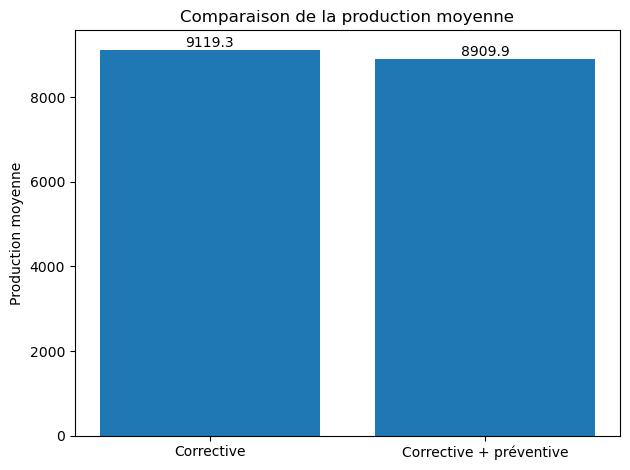

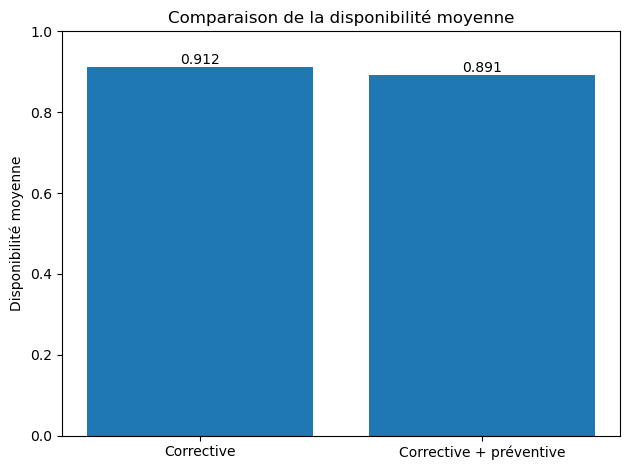

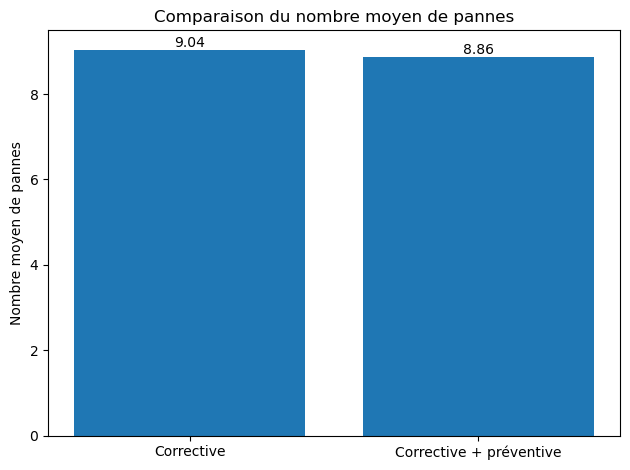

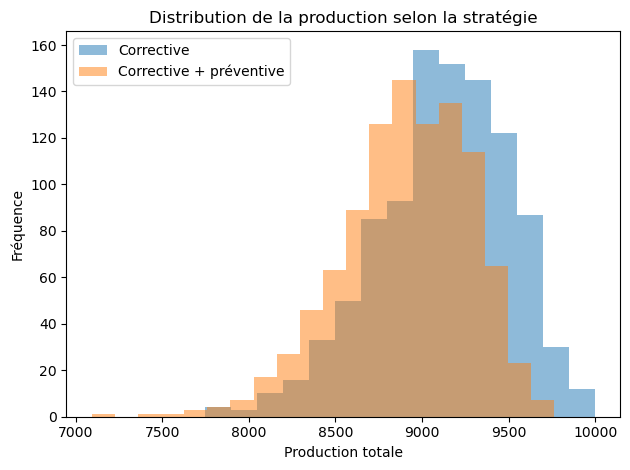

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Simulation d'une trajectoire (une seul)

def simuler_une_trajectoire(T, r, lam, mu,
                            strategy="corrective",
                            T_prev=None, D_prev=None,
                            rng=None):
    
    if rng is None:
        rng = np.random.default_rng()

    t = 0.0
    H_f = 0.0      # temps en fonctionnement
    H_p = 0.0      # temps en panne
    H_prev = 0.0   # temps en maintenance préventive
    N_pannes = 0
    etat = "fonctionnement"

    # temps de fonctionnement cumulé depuis la dernière préventive
    H_f_depuis_prev = 0.0

    # Boucle sur le temps
    while t < T:
        if etat == "fonctionnement":
            # Temps jusqu'à la prochaine panne ~ Exp(lam)
            temps_jusqu_panne = rng.exponential(1.0 / lam)

            # Temps restant avant la prochaine maintenance préventive
            if strategy == "corrective_preventive":
                temps_restant_prev = T_prev - H_f_depuis_prev
                if temps_restant_prev < 0:
                    temps_restant_prev = 0.0
            else:
                temps_restant_prev = np.inf  # pas de préventive

            # Temps jusqu'à la fin de l'horizon
            temps_jusqu_fin = T - t

            # Prochain événement
            delta = min(temps_jusqu_panne, temps_restant_prev, temps_jusqu_fin)

            # Pendant delta, la machine fonctionne
            H_f += delta
            H_f_depuis_prev += delta
            t += delta

            # On regarde ce qui s'est passé
            if t >= T:
                break
            elif delta == temps_jusqu_panne:
                etat = "panne"
                N_pannes += 1
            elif delta == temps_restant_prev and strategy == "corrective_preventive":
                etat = "maintenance_preventive"

        elif etat == "panne":
            # Durée de réparation ~ Exp(mu)
            duree_reparation = rng.exponential(1.0 / mu)
            delta = min(duree_reparation, T - t)

            H_p += delta
            t += delta

            if t >= T:
                break

            etat = "fonctionnement"

        elif etat == "maintenance_preventive":
            # Durée de la préventive (ici supposée fixe)
            duree_prev = D_prev
            delta = min(duree_prev, T - t)

            H_prev += delta
            t += delta

            # Après préventive, on remet à zéro le compteur de fonctionnement
            H_f_depuis_prev = 0.0

            if t >= T:
                break

            etat = "fonctionnement"

        else:
            raise ValueError("État inconnu : " + str(etat))

    # Indicateurs
    P = r * H_f            # production
    A = H_f / T            # disponibilité

    return P, A, N_pannes, H_f, H_p, H_prev


# 2. Monte Carlo (N simulation et calcule les moyennes, écarts-types et intervalles de confiance )

def monte_carlo(T, r, lam, mu,
                strategy="corrective",
                T_prev=None, D_prev=None,
                N=1000, seed=None):

    rng = np.random.default_rng(seed) # seed pour donner les meme resultat tjr 

    P_vals = np.zeros(N)
    A_vals = np.zeros(N)
    N_vals = np.zeros(N)

    for i in range(N):
        P, A, N_pannes, _, _, _ = simuler_une_trajectoire(
            T=T, r=r, lam=lam, mu=mu,
            strategy=strategy,
            T_prev=T_prev, D_prev=D_prev,
            rng=rng
        )
        P_vals[i] = P
        A_vals[i] = A
        N_vals[i] = N_pannes

    def stats(x):
        moy = np.mean(x)
        std = np.std(x, ddof=1)
        IC_inf = moy - 1.96 * std / np.sqrt(N)
        IC_sup = moy + 1.96 * std / np.sqrt(N)
        return moy, std, (IC_inf, IC_sup)

    moy_P, std_P, IC_P = stats(P_vals)
    moy_A, std_A, IC_A = stats(A_vals)
    moy_N, std_N, IC_N = stats(N_vals)

    resultats = {
        "P": {"moyenne": moy_P, "ecart_type": std_P, "IC95": IC_P},
        "A": {"moyenne": moy_A, "ecart_type": std_A, "IC95": IC_A},
        "N_pannes": {"moyenne": moy_N, "ecart_type": std_N, "IC95": IC_N},
    }

    return resultats, P_vals, A_vals, N_vals


# ==========================
# 3. Affichage texte
# ==========================

def afficher_resultats(nom_strategie, res):
    print(f"\n=== {nom_strategie} ===")
    print(f"Production moyenne     : {res['P']['moyenne']:.2f}")
    print(f"  Écart-type           : {res['P']['ecart_type']:.2f}")
    print(f"  IC95% Production     : [{res['P']['IC95'][0]:.2f} ; {res['P']['IC95'][1]:.2f}]")

    print(f"Disponibilité moyenne  : {res['A']['moyenne']:.4f}")
    print(f"  Écart-type           : {res['A']['ecart_type']:.4f}")
    print(f"  IC95% Disponibilité  : [{res['A']['IC95'][0]:.4f} ; {res['A']['IC95'][1]:.4f}]")

    print(f"Nombre moyen de pannes : {res['N_pannes']['moyenne']:.3f}")
    print(f"  Écart-type           : {res['N_pannes']['ecart_type']:.3f}")
    print(f"  IC95% Nb pannes      : [{res['N_pannes']['IC95'][0]:.3f} ; {res['N_pannes']['IC95'][1]:.3f}]")


# ==========================
# 4. Graphiques séparés
# ==========================

def tracer_barres_separees(res_corr, res_prev):
    """
    Trace trois graphiques à barres séparés :
    - Production moyenne
    - Disponibilité moyenne
    - Nombre moyen de pannes
    pour les deux stratégies.
    """

    # --- 1) Production ---
    plt.figure()
    x = np.arange(2)
    prod_vals = [res_corr['P']['moyenne'], res_prev['P']['moyenne']]
    plt.bar(x, prod_vals, tick_label=['Corrective', 'Corrective + préventive'])
    plt.ylabel('Production moyenne')
    plt.title('Comparaison de la production moyenne')

    # annoter les valeurs
    for i, v in enumerate(prod_vals):
        plt.text(i, v, f'{v:.1f}', ha='center', va='bottom')
    plt.tight_layout()

    # --- 2) Disponibilité ---
    plt.figure()
    disp_vals = [res_corr['A']['moyenne'], res_prev['A']['moyenne']]
    plt.bar(x, disp_vals, tick_label=['Corrective', 'Corrective + préventive'])
    plt.ylabel('Disponibilité moyenne')
    plt.title('Comparaison de la disponibilité moyenne')
    for i, v in enumerate(disp_vals):
        plt.text(i, v, f'{v:.3f}', ha='center', va='bottom')
    plt.ylim(0, 1)   # la disponibilité est entre 0 et 1
    plt.tight_layout()

    # --- 3) Nombre de pannes ---
    plt.figure()
    pannes_vals = [res_corr['N_pannes']['moyenne'], res_prev['N_pannes']['moyenne']]
    plt.bar(x, pannes_vals, tick_label=['Corrective', 'Corrective + préventive'])
    plt.ylabel('Nombre moyen de pannes')
    plt.title('Comparaison du nombre moyen de pannes')
    for i, v in enumerate(pannes_vals):
        plt.text(i, v, f'{v:.2f}', ha='center', va='bottom')
    plt.tight_layout()

    plt.show()


def tracer_histogrammes_production(P_corr, P_prev):
    """Histogrammes de la production pour chaque stratégie (optionnel)."""
    plt.figure()
    plt.hist(P_corr, bins=15, alpha=0.5, label='Corrective')
    plt.hist(P_prev, bins=20, alpha=0.5, label='Corrective + préventive')
    plt.xlabel('Production totale')
    plt.ylabel('Fréquence')
    plt.title('Distribution de la production selon la stratégie')
    plt.legend()
    plt.tight_layout()
    plt.show()


# ==========================
# 5. Programme principal
# ==========================

if __name__ == "__main__":
    # Paramètres
    T = 1000.0       # heures
    r = 10.0         # pièces / heure
    lam = 1/100.0    # une panne toutes les 100 h en moyenne
    mu = 1/10.0      # réparation moyenne de 10 h
    N = 1000         # nombre de simulations
    seed = 42

    # Stratégie 1 : corrective seule
    res_corr, P_corr, A_corr, N_corr = monte_carlo(
        T=T, r=r, lam=lam, mu=mu,
        strategy="corrective",
        N=N, seed=seed
    )

    # Stratégie 2 : corrective + préventive
    res_prev, P_prev, A_prev, N_prev = monte_carlo(
        T=T, r=r, lam=lam, mu=mu,
        strategy="corrective_preventive",
        T_prev=200.0, D_prev=5.0,
        N=N, seed=seed+1
    )

    # Affichage texte
    afficher_resultats("Stratégie corrective seule", res_corr)
    afficher_resultats("Stratégie corrective + préventive", res_prev)

    # Graphiques séparés pour les 3 grandeurs
    tracer_barres_separees(res_corr, res_prev)

    # Histogrammes de production (facultatif)
    tracer_histogrammes_production(P_corr, P_prev)
